# GLM-5.2 (Fireworks) vs Claude Opus 4.8 (Anthropic) — GSM8K speed showcase

Runs both models on the same **100-row GSM8K sample** and compares them on two axes:

- **Accuracy** — graded with [eval-protocol](https://github.com/eval-protocol/python-sdk)'s `SingleTurnRolloutProcessor` (the harness used across this cookbook).
- **Speed** — every rollout is wrapped in a `time.perf_counter()` clock to capture per-request latency, plus an end-to-end throughput number for the whole run.

At the end we draw a side-by-side speed comparison chart.

**Prereqs:** `FIREWORKS_API_KEY` and `ANTHROPIC_API_KEY` in `training/.env` or your shell.


In [1]:
# Run once if imports fail (uses the notebook kernel's Python).
import sys
!{sys.executable} -m pip install -q -e "../../.[eval]" matplotlib

In [ ]:
# --- edit these ---
FIREWORKS_5_2_MODEL = "fireworks_ai/accounts/fireworks/models/glm-5p2"   # GLM-5.2 serverless
FIREWORKS_5_1_MODEL = "fireworks_ai/accounts/fireworks/models/glm-5p1"   # GLM-5.1 serverless
ANTHROPIC_MODEL = "anthropic/claude-opus-4-8"                        # Claude Opus 4.8
OPENAI_MODEL = "openai/gpt-5.5"

MODELS = {
    "GLM-5.2 (Fireworks)": FIREWORKS_5_2_MODEL,
    "GLM-5.1 (Fireworks)": FIREWORKS_5_1_MODEL,
    "Opus 4.8 (Anthropic)": ANTHROPIC_MODEL,
    "GPT-5 (OpenRouter)": OPENAI_MODEL,
}

MAX_ROWS = 64
DATASET_URL = "https://raw.githubusercontent.com/eval-protocol/python-sdk/main/development/gsm8k_sample.jsonl"
TEMPERATURE = 1
# Concurrency shapes the speed story:
#   high (>= MAX_ROWS)  -> per-request latency is "pure" (little queueing)
#   low (e.g. 4-8)      -> measures throughput under load
# We report BOTH per-request latency and end-to-end throughput, so 8 is a sane middle.
CONCURRENCY = 32

In [3]:
import asyncio
import os
import re
import time
from pathlib import Path

import litellm
from dotenv import load_dotenv
from eval_protocol.common_utils import load_jsonl
from eval_protocol.models import EvaluateResult, EvaluationRow
from eval_protocol.pytest import SingleTurnRolloutProcessor
from eval_protocol.pytest.types import RolloutProcessorConfig

training_dir = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "training" and (p / "pyproject.toml").exists()),
    Path("../../").resolve(),
)
load_dotenv(training_dir / ".env")

missing = [k for k in ("FIREWORKS_API_KEY", "ANTHROPIC_API_KEY", "OPENAI_API_KEY") if not os.getenv(k)]
if missing:
    raise EnvironmentError(f"Missing {missing}. Set them in {training_dir / '.env'} or your shell.")

# Strict mode: do not silently drop malformed/unsupported LiteLLM params.
litellm.drop_params = False
# litellm._turn_on_debug()

/opt/homebrew/Caskroom/miniconda/base/envs/cookbook/lib/python3.12/site-packages/eval_protocol/models.py:1156: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  class TaskDefinitionModel(BaseModel):


In [4]:
def load_rows(url: str, max_rows: int | None) -> list[EvaluationRow]:
    raw = load_jsonl(url)
    rows = [EvaluationRow(**item) for item in raw]
    if max_rows is not None:
        rows = rows[:max_rows]
    for i, row in enumerate(rows):
        row.input_metadata.row_id = row.input_metadata.row_id or f"row-{i}"
    return rows


rows = load_rows(DATASET_URL, MAX_ROWS)
print(f"Loaded {len(rows)} GSM8K rows")

Loaded 50 GSM8K rows


In [5]:
_ANSWER_TAG_RE = re.compile(r"<answer>\s*(.*?)\s*</answer>", re.IGNORECASE | re.DOTALL)
_DIGITS_RE = re.compile(r"(-?\d+(?:\.\d+)?)")


def extract_answer(text: str) -> str | None:
    """Pull the numeric answer from <answer> tags (Eval Protocol GSM8K format)."""
    if not text:
        return None
    m = _ANSWER_TAG_RE.search(text)
    chunk = m.group(1) if m else text
    digits = _DIGITS_RE.findall(chunk.replace(",", ""))
    return digits[-1] if digits else None


def model_response(row: EvaluationRow) -> str:
    return str(row.messages[-1].content)


def grade_regex(row: EvaluationRow) -> EvaluateResult:
    pred = extract_answer(model_response(row))
    gt = extract_answer(str(row.ground_truth))
    if pred is None or gt is None:
        return EvaluateResult(score=0.0, reason=f"missing answer (pred={pred}, gt={gt})")
    ok = pred == gt
    return EvaluateResult(score=1.0 if ok else 0.0, reason=f"pred={pred}, gt={gt}")

## Run + clock both models

`SingleTurnRolloutProcessor` returns one awaitable per row. We wrap each in a `perf_counter` clock to get its individual completion time, and bracket the whole `gather` to get end-to-end wall-clock (the throughput number).

In [6]:
import copy


async def benchmark_model(name: str, model: str, rows: list[EvaluationRow]) -> dict:
    # Fresh copy per model so rollouts don't clobber each other's messages.
    model_rows = [copy.deepcopy(r) for r in rows]

    processor = SingleTurnRolloutProcessor(drop_trailing_assistant_messages=True)
    config = RolloutProcessorConfig(
        completion_params={"model": model, "temperature": TEMPERATURE},
        mcp_config_path="",
        semaphore=asyncio.Semaphore(CONCURRENCY),
    )

    async def timed(coro):
        t0 = time.perf_counter()
        row = await coro
        return row, time.perf_counter() - t0

    rollout_tasks = processor(model_rows, config)

    wall_start = time.perf_counter()
    completed = await asyncio.gather(*(timed(t) for t in rollout_tasks), return_exceptions=True)
    wall_total = time.perf_counter() - wall_start

    latencies, scores, errors = [], [], 0
    for item in completed:
        if isinstance(item, Exception):
            errors += 1
            continue
        row, dt = item
        latencies.append(dt)
        row.evaluation_result = grade_regex(row)
        scores.append(row.evaluation_result.score)

    n = len(scores)
    print(f"{name}: {n} ok, {errors} errors, wall {wall_total:.1f}s")
    return {
        "name": name,
        "model": model,
        "latencies": latencies,
        "scores": scores,
        "errors": errors,
        "wall_total": wall_total,
        "n": n,
    }


results = {}
for name, model in MODELS.items():
    print(f"--- {name} ({model}) ---")
    results[name] = await benchmark_model(name, model, rows)

--- GLM-5.2 (Fireworks) (fireworks_ai/accounts/fireworks/models/glm-5p2) ---
GLM-5.2 (Fireworks): 50 ok, 0 errors, wall 253.3s
--- GLM-5.1 (Fireworks) (fireworks_ai/accounts/fireworks/models/glm-5p1) ---
GLM-5.1 (Fireworks): 50 ok, 0 errors, wall 146.1s
--- Opus 4.8 (Anthropic) (anthropic/claude-opus-4-8) ---
Opus 4.8 (Anthropic): 50 ok, 0 errors, wall 48.1s
--- GPT-5 (OpenRouter) (openai/gpt-5.5) ---
GPT-5 (OpenRouter): 50 ok, 0 errors, wall 65.9s


In [7]:
import statistics as st


def summarize(r: dict) -> dict:
    lat = sorted(r["latencies"])
    n = r["n"]
    p95 = lat[min(len(lat) - 1, int(0.95 * len(lat)))] if lat else float("nan")
    return {
        "name": r["name"],
        "accuracy": (sum(r["scores"]) / n) if n else 0.0,
        "mean_latency": st.mean(lat) if lat else float("nan"),
        "median_latency": st.median(lat) if lat else float("nan"),
        "p95_latency": p95,
        "throughput_rpm": (n / r["wall_total"] * 60) if r["wall_total"] else 0.0,
        "wall_total": r["wall_total"],
        "errors": r["errors"],
    }


summaries = {name: summarize(r) for name, r in results.items()}

hdr = f"{'Model':24} {'Acc':>6} {'mean(s)':>8} {'med(s)':>8} {'p95(s)':>8} {'rows/min':>9} {'wall(s)':>8}"
print(hdr)
print("-" * len(hdr))
for s in summaries.values():
    print(f"{s['name']:24} {s['accuracy']:>6.1%} {s['mean_latency']:>8.2f} "
          f"{s['median_latency']:>8.2f} {s['p95_latency']:>8.2f} "
          f"{s['throughput_rpm']:>9.1f} {s['wall_total']:>8.1f}")

Model                       Acc  mean(s)   med(s)   p95(s)  rows/min  wall(s)
-----------------------------------------------------------------------------
GLM-5.2 (Fireworks)       82.0%    79.45    75.21   154.32      11.8    253.3
GLM-5.1 (Fireworks)       96.0%    76.38    74.79   141.56      20.5    146.1
Opus 4.8 (Anthropic)      94.0%    26.64    27.51    46.28      62.3     48.1
GPT-5 (OpenRouter)        90.0%    33.65    33.32    61.57      45.5     65.9


## Speed comparison chart

/var/folders/0h/c6c4v8153bz0v35w1mcvqvpw0000gn/T/ipykernel_66463/2371983850.py:29: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot([results[n]["latencies"] for n in names], showfliers=False, vert=False)


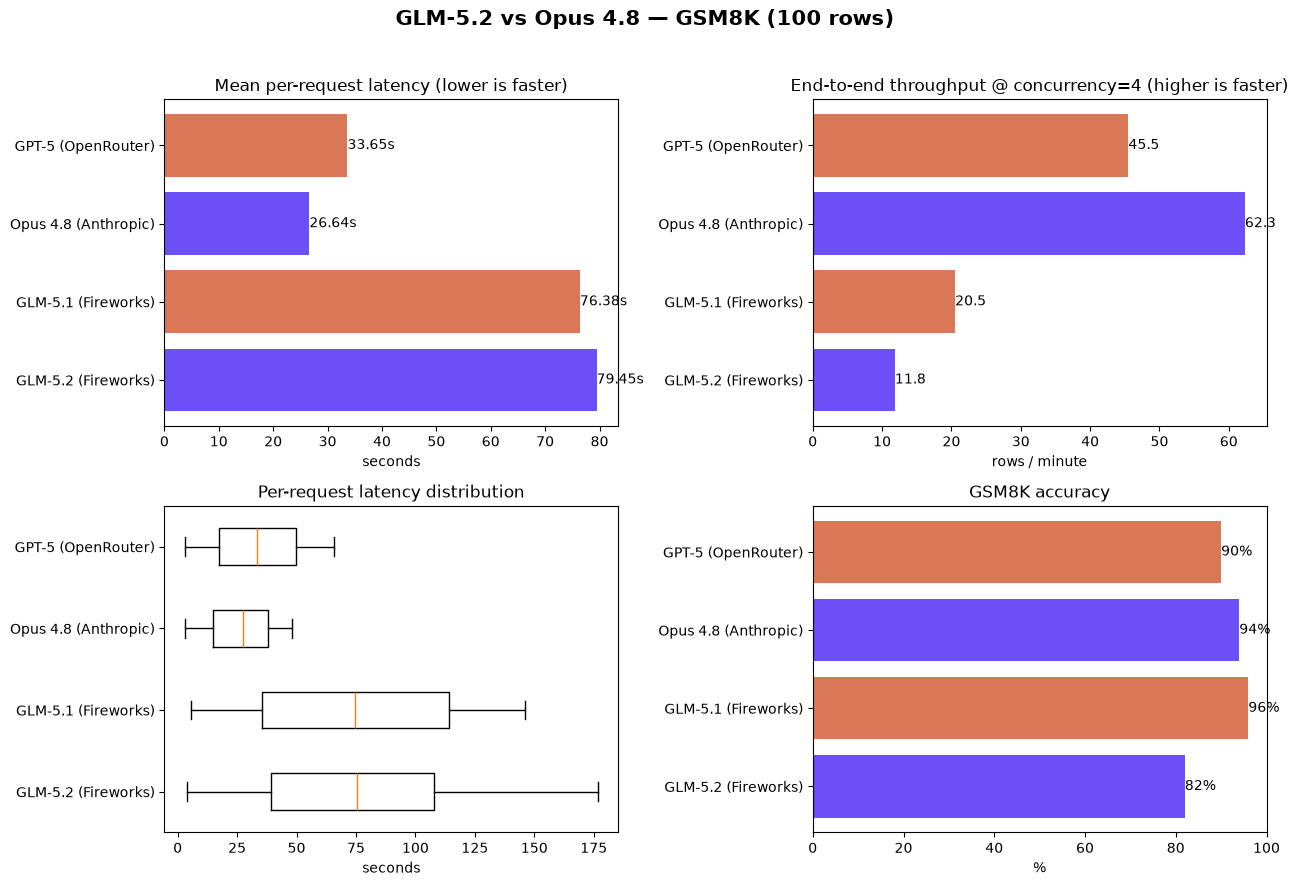

Saved gsm8k_speed_comparison.png


In [10]:
import matplotlib.pyplot as plt

names = list(summaries.keys())
colors = ["#6C4FF6", "#D97757"]  # Fireworks purple, Anthropic clay

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("GLM-5.2 vs Opus 4.8 — GSM8K (100 rows)", fontsize=15, fontweight="bold")

# 1. Mean per-request latency (lower = faster)
ax = axes[0, 0]
vals = [summaries[n]["mean_latency"] for n in names]
bars = ax.barh(names, vals, color=colors)
ax.set_title("Mean per-request latency (lower is faster)")
ax.set_xlabel("seconds")
for b, v in zip(bars, vals):
    ax.text(v, b.get_y() + b.get_height() / 2, f"{v:.2f}s", va="center", ha="left")

# 2. Throughput (higher = faster)
ax = axes[0, 1]
vals = [summaries[n]["throughput_rpm"] for n in names]
bars = ax.barh(names, vals, color=colors)
ax.set_title(f"End-to-end throughput @ concurrency={CONCURRENCY} (higher is faster)")
ax.set_xlabel("rows / minute")
for b, v in zip(bars, vals):
    ax.text(v, b.get_y() + b.get_height() / 2, f"{v:.1f}", va="center", ha="left")

# 3. Latency distribution
ax = axes[1, 0]
bp = ax.boxplot([results[n]["latencies"] for n in names], showfliers=False, vert=False)
ax.set_title("Per-request latency distribution")
ax.set_xlabel("seconds")
# Set yticks/labels manually since 'labels' kwarg is not supported for Axes.boxplot when horizontal
ax.set_yticks(range(1, len(names) + 1))
ax.set_yticklabels(names)

# 4. Accuracy (context for the speed numbers)
ax = axes[1, 1]
vals = [summaries[n]["accuracy"] * 100 for n in names]
bars = ax.barh(names, vals, color=colors)
ax.set_title("GSM8K accuracy")
ax.set_xlabel("%")
ax.set_xlim(0, 100)
for b, v in zip(bars, vals):
    ax.text(v, b.get_y() + b.get_height() / 2, f"{v:.0f}%", va="center", ha="left")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("gsm8k_speed_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved gsm8k_speed_comparison.png")

### Notes

- **GLM-5.2 is MoE and nondeterministic even at `temperature=0`** — accuracy can swing across runs on a 100-row sample. The point of this notebook is the **speed** axis; treat the accuracy bar as directional, and average several runs (or raise `MAX_ROWS`) if you need a trustworthy accuracy delta.
- `CONCURRENCY` controls the speed story. Raise it toward `MAX_ROWS` for near-pure per-request latency; lower it to stress throughput under load.
- Both providers are hit through `litellm` via eval-protocol, so latency includes network RTT from wherever this runs.